![logo](https://www.python.org/static/community_logos/python-powered-h-70x91.png)
# **<font color="DarkBlue">Estadística Inferencial con Python - Parte 2**
### *Pruebas de Hipótesis para Dos o Más Poblaciones (Muestras Independientes y Relacionadas), Análisis de Varianza (ANOVA), Pruebas No Paramétricas y Análisis de Asociación Cualitativa (Chi-cuadrado)*


In [1]:
##warnings
import warnings
warnings.filterwarnings('ignore')

## **<font color="DarkBlue">Librerías**
Importaremos las herramientas necesarias para la modelación estadística avanzada y la construcción de visualizaciones complejas e interactivas.


In [2]:
# Herramientas numéricas y de datos
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Herramientas de visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100


## **<font color="DarkBlue">1. Comparación de Medias de Dos Poblaciones (Dos Muestras)**
Una de las aplicaciones más frecuentes en la investigación científica y la analítica de negocios consiste en comparar los promedios de dos grupos (ejemplo: tratamiento vs. control, usuarios web A vs. usuarios B).

### **Caso 1.1: Prueba t para Muestras Independientes (Varianzas iguales y varianzas desiguales)**
Esta prueba se utiliza cuando comparamos dos grupos independientes y no relacionados.
Antes de ejecutar la prueba t, es fundamental evaluar si se cumplen los supuestos fundamentales:
1. **Normalidad** en cada grupo (evaluada mediante la prueba de Shapiro-Wilk).
2. **Homocedasticidad** o igualdad de varianzas (evaluada mediante la prueba de Levene).

**Ejemplo Práctico:** Una empresa de e-commerce desea evaluar si el tiempo promedio de permanencia en la página web varía de manera significativa según el diseño de interfaz utilizado (Diseño A vs. Diseño B).


### Prueba t para Muestras Independientes (Test A/B): Cuadro Optimizado

| Paso / Concepto | Significado Teórico | Aplicación al Ejemplo (Diseño A vs B) |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**El Objetivo**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">Comparar 2 Grupos Distintos</span> | • Comparar la Media del Grupo A contra la Media del Grupo B.<br>• Confirmar si la diferencia observada es real o solo casualidad estadísica ("ruido"). |
| <span style="color:#2E7D32">**Paso 1: Normalidad**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">Test de Shapiro-Wilk</span> | • Requisito: Los datos deben seguir una curva normal.<br>• ¿Los tiempos de permanencia de los usuarios forman una campana de Gauss tanto en el Diseño A como en el B? |
| <span style="color:#E65100">**Paso 2: Varianzas**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">Test de Levene</span> | • Requisito: Homocedasticidad (varianzas iguales).<br>• ¿La dispersión (variabilidad) de los minutos de navegación en el Diseño A es similar a la del Diseño B? |
| <span style="color:#6A1B9A">**Paso 3: Elección del Test**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">t clásica o t de Welch</span> | • Si Levene confirma varianzas iguales $\rightarrow$ usamos la **prueba t clásica**.<br>• Si las varianzas son muy distintas $\rightarrow$ la matemática se ajusta usando la **prueba t de Welch**. |
| <span style="color:#C62828">**Las Hipótesis**</span> | <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">$H_0: \mu_A = \mu_B$<br>$H_1: \mu_A \neq \mu_B$</span> | • **$H_0$:** Ningún diseño es mejor; ambos retienen a la gente el mismo tiempo en promedio.<br>• **$H_1$:** Existe una diferencia real en el comportamiento de los usuarios según la interfaz. |

> **Nota Teórica Crucial:** Hablamos de muestras **independientes** porque los usuarios que navegan el Diseño A son personas totalmente distintas a las que navegan el Diseño B. El comportamiento de un grupo no influye ni depende del comportamiento del otro.

In [3]:
np.random.seed(123)
# Simulación de datos de tiempos en minutos
tiempo_a = np.random.normal(loc=12.5, scale=3.0, size=35) # Diseño A
tiempo_b = np.random.normal(loc=14.2, scale=3.5, size=40) # Diseño B

# Supuesto 1: Prueba de Normalidad de Shapiro-Wilk (H0: Datos distribuidos normalmente)
shapiro_a = stats.shapiro(tiempo_a)
shapiro_b = stats.shapiro(tiempo_b)

print("Supuesto de Normalidad (p-valores):")
print(f"Grupo A: {shapiro_a.pvalue:.4f} | Grupo B: {shapiro_b.pvalue:.4f}")
print("Ambos p-valores > 0.05, por lo que asumimos normalidad en ambos grupos.\n")

# Supuesto 2: Prueba de Homocedasticidad de Levene (H0: Varianzas iguales)
levene_test = stats.levene(tiempo_a, tiempo_b)
print(f"Prueba de Homocedasticidad de Levene (p-valor): {levene_test.pvalue:.4f}")
if levene_test.pvalue > 0.05:
    print("p-valor > 0.05, asumimos que las varianzas son iguales (Homocedasticidad).")
    # Prueba t convencional
    t_ind, p_ind = stats.ttest_ind(tiempo_a, tiempo_b, equal_var=True)
else:
    print("p-valor <= 0.05, asumimos varianzas distintas. Usamos Welch's t-test.")
    # Prueba t de Welch
    t_ind, p_ind = stats.ttest_ind(tiempo_a, tiempo_b, equal_var=False)

print(f"\nEstadístico de prueba t: {t_ind:.4f}")
print(f"p-valor resultante: {p_ind:.6f}")
alpha = 0.05
if p_ind <= alpha:
    print("Decisión: Se rechaza la hipótesis nula.")
    print("Conclusión: El Diseño B retiene a los usuarios significativamente más tiempo que el Diseño A.")
else:
    print("Decisión: No se puede rechazar la hipótesis nula.")
    print("Conclusión: No hay diferencias significativas de rendimiento entre ambos diseños.")


Supuesto de Normalidad (p-valores):
Grupo A: 0.5243 | Grupo B: 0.8977
Ambos p-valores > 0.05, por lo que asumimos normalidad en ambos grupos.

Prueba de Homocedasticidad de Levene (p-valor): 0.8992
p-valor > 0.05, asumimos que las varianzas son iguales (Homocedasticidad).

Estadístico de prueba t: -2.9043
p-valor resultante: 0.004866
Decisión: Se rechaza la hipótesis nula.
Conclusión: El Diseño B retiene a los usuarios significativamente más tiempo que el Diseño A.


### **Visualización comparativa de los grupos**
Graficaremos un diagrama de caja y bigotes (Boxplot) superpuesto con puntos individuales para comparar de forma intuitiva los dos grupos.


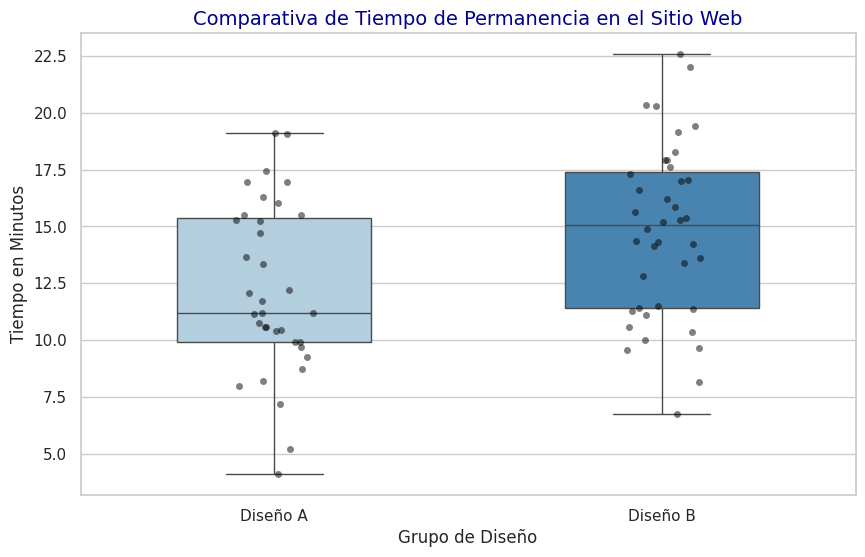

In [4]:
# Creamos un DataFrame consolidado para facilitar la graficación
df_tiempos = pd.DataFrame({
    'Tiempo': np.concatenate([tiempo_a, tiempo_b]),
    'Diseño': ['Diseño A'] * len(tiempo_a) + ['Diseño B'] * len(tiempo_b)
})

sns.boxplot(x='Diseño', y='Tiempo', data=df_tiempos, palette='Blues', width=0.5)
sns.stripplot(x='Diseño', y='Tiempo', data=df_tiempos, color='black', alpha=0.5, size=5)
plt.title("Comparativa de Tiempo de Permanencia en el Sitio Web", fontsize=14, color="DarkBlue")
plt.xlabel("Grupo de Diseño")
plt.ylabel("Tiempo en Minutos")
plt.show()


### Análisis Visual: Resultados del Test A/B (Tiempo de Permanencia)

| Componente / Observación | Qué vemos en el Gráfico | Interpretación (Contexto A/B Test) |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**Tipo de Visualización**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">Boxplot + Puntos</span> | • Muestra los cuartiles (cajas) y simultáneamente cada usuario individual (puntos grises).<br>• Permite ver la forma real de los datos, no solo el promedio. |
| <span style="color:#2E7D32">**Diseño A (Celeste)**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">Mediana $\approx 11$ min</span> | • Es nuestro grupo de control.<br>• El 50% central de los usuarios navega entre 10 y 15 minutos aproximadamente. |
| <span style="color:#E65100">**Diseño B (Azul Oscuro)**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">Mediana $\approx 15$ min</span> | • Es nuestro grupo de tratamiento (la nueva variante).<br>• El 50% central de los usuarios navega entre 11.5 y 17.5 minutos. |
| <span style="color:#6A1B9A">**Comparación de Medias**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">Desplazamiento Vertical</span> | • La caja del Diseño B está visiblemente "más arriba" que la del Diseño A.<br>• Esto nos da una fuerte intuición visual de que **rechazaremos la $H_0$**. |
| <span style="color:#C62828">**Dispersión y Supuestos**</span> | <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">Cajas de altura similar</span> | • La altura de la parte coloreada (Rango Intercuartílico) es muy parecida en ambos grupos.<br>• Esto sugiere visualmente que hay **Homocedasticidad** (varianzas iguales), validando el uso de la prueba t clásica. |

> **Veredicto Preliminar (Visual):** > Antes de correr el código de la prueba t, el gráfico ya nos está "gritando" que el **Diseño B** es más efectivo para retener a los usuarios en el e-commerce. La prueba estadística simplemente confirmará si esta diferencia visual es matemáticamente significativa y no producto del azar de esta muestra particular.

---
### **Caso 1.2: Prueba t para Muestras Relacionadas / Pareadas**
Se aplica cuando los mismos sujetos se miden en dos momentos temporales distintos (por ejemplo, mediciones antes y después de aplicar un tratamiento farmacéutico o programa educativo).

**Ejemplo Práctico:** Se evalúa la presión arterial diastólica de 15 pacientes antes de tomar un medicamento regulador y 4 horas después.


### Prueba t para Muestras Relacionadas (Pareadas): Cuadro Optimizado

| Paso / Concepto | Significado Teórico | Aplicación al Ejemplo (Presión Arterial) |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**El Objetivo**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">Medidas Repetidas</span> | • Evaluar el impacto de una intervención en los **mismos sujetos** a lo largo del tiempo.<br>• Ej: El mismo paciente es medido antes y después de la pastilla. |
| <span style="color:#2E7D32">**La Matemática ($\Delta$)**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">Cálculo de Diferencias</span> | • Ya no hay "Media A" vs "Media B".<br>• Calculamos $Diferencia = Después - Antes$ para cada uno de los 15 pacientes. |
| <span style="color:#E65100">**El Supuesto Previo**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">Normalidad de $\Delta$</span> | • **Ojo:** No importa si la presión "Antes" o "Después" es normal.<br>• Lo único que debe pasar la prueba de normalidad (Shapiro-Wilk) es la columna de las *diferencias*. |
| <span style="color:#6A1B9A">**Las Hipótesis**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">$H_0: \mu_{\Delta} = 0$<br>$H_1: \mu_{\Delta} < 0$</span> | • **$H_0$:** La pastilla no hizo nada (el promedio de las diferencias es CERO).<br>• **$H_1$:** La pastilla bajó la presión (el promedio de las diferencias es negativo). |
| <span style="color:#C62828">**Regla de Decisión**</span> | <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">$p$-valor vs $\alpha$</span> | • Si $p < 0.05$, la reducción observada en la presión es demasiado grande para ser pura casualidad. Rechazamos $H_0$. |

> **Nota Teórica Crucial (Poder Estadístico):** Usar muestras pareadas es estadísticamente "más poderoso" que usar muestras independientes. ¿Por qué? Porque **elimina el ruido individual**. Al comparar a Juan Pérez consigo mismo, eliminamos variables que ensucian los datos como su peso, genética, o dieta. Cada paciente actúa como su propio grupo de control.

In [5]:
np.random.seed(88)
antes = np.random.normal(loc=95, scale=6, size=15)
# Simulamos el descenso de presión sistemático para cada paciente
despues = antes - np.random.normal(loc=8, scale=4, size=15)

# Ejecutamos la prueba t pareada
t_rel, p_rel = stats.ttest_rel(antes, despues)

print(f"Presión media antes del fármaco: {np.mean(antes):.2f} mmHg")
print(f"Presión media después del fármaco: {np.mean(despues):.2f} mmHg")
print(f"Estadístico t pareado: {t_rel:.4f}")
print(f"p-valor: {p_rel:.6f}")

if p_rel <= 0.05:
    print("\nConclusión: El fármaco disminuyó la presión arterial diastólica de forma altamente significativa.")
else:
    print("\nConclusión: No se detectan diferencias con el uso del fármaco.")


Presión media antes del fármaco: 95.54 mmHg
Presión media después del fármaco: 87.73 mmHg
Estadístico t pareado: 7.3891
p-valor: 0.000003

Conclusión: El fármaco disminuyó la presión arterial diastólica de forma altamente significativa.


### **Visualización de evolución por Paciente (Gráfico de Perfil)**


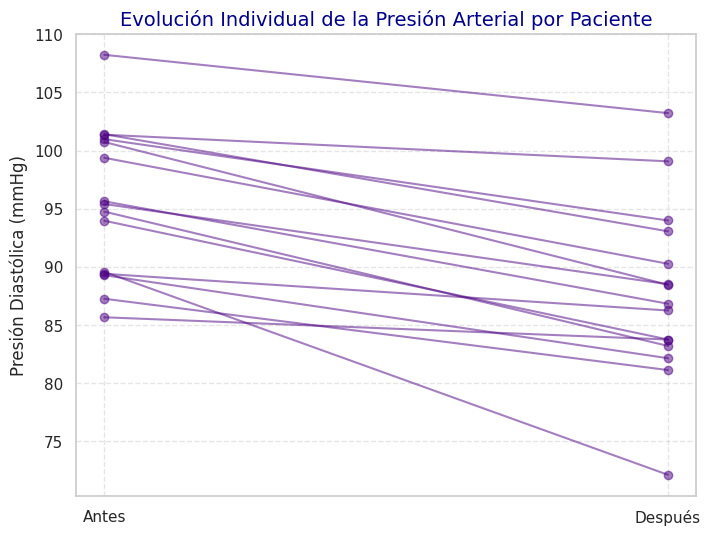

In [6]:
plt.figure(figsize=(8, 6))
for i in range(len(antes)):
    plt.plot(['Antes', 'Después'], [antes[i], despues[i]], color='indigo', alpha=0.5, marker='o')

plt.title("Evolución Individual de la Presión Arterial por Paciente", fontsize=14, color="DarkBlue")
plt.ylabel("Presión Diastólica (mmHg)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Análisis Visual: Resultados de Muestras Pareadas (Presión Arterial)

| Componente del Gráfico | Qué vemos en la Imagen | Interpretación (Contexto Prueba Pareada) |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**Tipo de Gráfico**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">Gráfico de Pendientes</span> | • Conecta dos puntos de datos a lo largo del tiempo.<br>• Es ideal para visualizar mediciones "Antes" y "Después" en los mismos individuos. |
| <span style="color:#2E7D32">**Las Líneas (Individuos)**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">15 Trayectorias Únicas</span> | • Cada línea representa a un **único paciente**.<br>• El gráfico anula el "ruido" comparando a cada persona exclusivamente consigo misma. |
| <span style="color:#E65100">**Dispersión Inicial (Eje Y)**</span>| <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">Puntos de partida variados</span> | • Los pacientes empezaron con presiones muy distintas (desde $\approx 85$ hasta casi $110$).<br>• En una prueba de muestras independientes, esta gran variabilidad ocultaría el efecto del medicamento. |
| <span style="color:#6A1B9A">**Dirección de la Pendiente**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">Tendencia Uniforme</span> | • **Absolutamente todas las líneas apuntan hacia abajo.**<br>• Esto indica que la diferencia matemática ($\Delta = \text{Después} - \text{Antes}$) es negativa para el 100% de la muestra. |

> **Veredicto Preliminar (Visual):** > La imagen es contundente. No importa si el paciente tenía la presión altísima o moderada al inicio; el medicamento logró reducirla en todos los casos sin excepción. Visualmente, podemos predecir con casi total seguridad que al ejecutar la prueba t pareada, el $p$-valor será extremadamente bajo ($p < 0.05$), llevando a un rechazo rotundo de la Hipótesis Nula ($H_0$).

## **<font color="DarkBlue">2. Análisis de Varianza (ANOVA) de una Vía**
Cuando queremos comparar simultáneamente las medias de **tres o más grupos**, utilizar múltiples pruebas t de forma repetida eleva el riesgo de cometer un Error Tipo I. En su lugar, aplicamos **ANOVA**.

**Hipótesis de ANOVA:**
- $H_0: \mu_1 = \mu_2 = \mu_3 = ... = \mu_k$ (Todos los promedios de grupo son iguales).
- $H_1:$ Al menos una de las medias de los grupos es diferente.

**Prueba Post-hoc (Tukey's HSD):** Si ANOVA resulta significativa ($p \le 0.05$), realizamos una prueba post-hoc para identificar exactamente cuáles parejas de grupos tienen diferencias estadísticas.

**Ejemplo Práctico:** Evaluemos las ventas logradas mediante 3 campañas publicitarias distintas (Campaña Redes Sociales, Campaña Email Marketing y Campaña Marketing de Influencers) aplicadas a 20 tiendas distintas para cada una.


### Análisis de Varianza (ANOVA de una Vía): Cuadro Optimizado

| Concepto / Componente | Significado Teórico | Aplicación al Ejemplo (Campañas MKT) |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**El Problema a Resolver**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">Comparar $\ge 3$ Grupos</span> | • Evita usar múltiples pruebas t que aumentarían el riesgo de Error Tipo I (falsos positivos). | • Queremos comparar simultáneamente el efecto de **3 canales distintos** en 60 tiendas (20 c/u). |
| <span style="color:#2E7D32">**Hipótesis Nula ($H_0$)**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">$\mu_1 = \mu_2 = \dots = \mu_k$</span> | • Afirma que no hay diferencias globales. Todos los grupos provienen de la misma población. | • Las 3 campañas (Redes, Email, Influencers) generan **exactamente el mismo** promedio de ventas. |
| <span style="color:#E65100">**Hipótesis Alternativa ($H_1$)**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">Al menos una $\mu$ difiere</span> | • **Ojo:** No significa que *todas* sean distintas entre sí, solo que al menos una se separa del resto. | • Al menos una de las campañas es significativamente mejor (o peor) que las otras. |
| <span style="color:#6A1B9A">**Estadístico y Decisión**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">Prueba F ($p$-valor)</span> | • Si $p \le 0.05$, se rechaza $H_0$. El test te dice que *hay* diferencias, pero **no te dice dónde están**. | • Si el $p$-valor es bajo, sabemos que el tipo de campaña importa para las ventas. |
| <span style="color:#C62828">**El Paso Final**</span> | <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">Prueba Post-hoc (Tukey)</span> | • Solo se ejecuta si ANOVA rechazó la $H_0$.<br>• Compara todas las parejas posibles ajustando el margen de error. | • Tukey comparará: Redes vs Email, Redes vs Influencers, y Email vs Influencers para coronar a la campaña ganadora. |

> **Nota Teórica Crucial:** ¿Por qué se llama Análisis de *Varianza* si estamos comparando *Medias*?
> Porque matemáticamente, ANOVA evalúa si la variabilidad **entre** los grupos (la diferencia entre las 3 campañas) es más grande que la variabilidad **dentro** de los grupos (la diferencia natural de ventas entre las 20 tiendas que usaron la misma campaña). Si la diferencia *entre* grupos "gana", entonces declaramos que los promedios son estadísticamente distintos.

In [7]:
np.random.seed(99)
# Simulación de ventas diarias por tienda según campaña
redes = np.random.normal(loc=120, scale=12, size=20)
email = np.random.normal(loc=112, scale=10, size=20)
influencers = np.random.normal(loc=132, scale=15, size=20)

# Ejecución del test ANOVA de una vía
f_stat, p_anova = stats.f_oneway(redes, email, influencers)

print(f"Estadístico F de ANOVA: {f_stat:.4f}")
print(f"p-valor: {p_anova:.7f}")

if p_anova <= 0.05:
    print("El test es significativo. Existen diferencias importantes entre las campañas.")
else:
    print("El test NO es significativo. No hay diferencias de rendimiento entre campañas.")


Estadístico F de ANOVA: 18.3389
p-valor: 0.0000007
El test es significativo. Existen diferencias importantes entre las campañas.


### **Prueba Post-Hoc: Comparación Múltiple de Tukey**
Al confirmarse que los grupos no son idénticos, determinaremos qué campaña específica sobresale.


In [8]:
# Estructuramos en DataFrame para Tukey HSD
df_ventas = pd.DataFrame({
    'Ventas': np.concatenate([redes, email, influencers]),
    'Campaña': ['Redes'] * 20 + ['Email'] * 20 + ['Influencers'] * 20
})

# Aplicamos Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_ventas['Ventas'],
                          groups=df_ventas['Campaña'],
                          alpha=0.05)
print(tukey)


      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj   lower    upper  reject
---------------------------------------------------------------
      Email Influencers  24.6841    0.0  14.8497 34.5186   True
      Email       Redes  10.7757 0.0286   0.9412 20.6101   True
Influencers       Redes -13.9085 0.0035 -23.7429  -4.074   True
---------------------------------------------------------------


### **Visualización Avanzada con Seaborn (Boxplot + Swarmplot)**


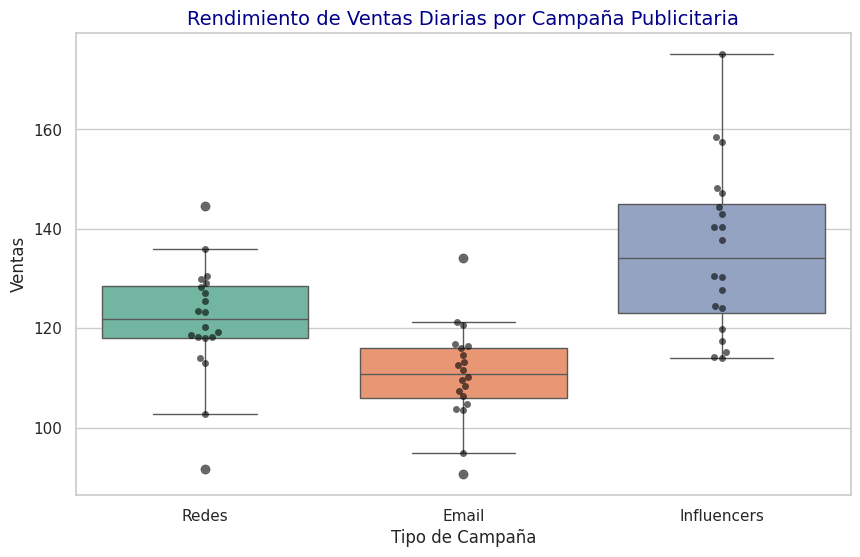

In [9]:
sns.boxplot(x='Campaña', y='Ventas', data=df_ventas, palette='Set2')
sns.swarmplot(x='Campaña', y='Ventas', data=df_ventas, color='black', alpha=0.6, size=5)
plt.title("Rendimiento de Ventas Diarias por Campaña Publicitaria", fontsize=14, color="DarkBlue")
plt.xlabel("Tipo de Campaña")
plt.ylabel("Ventas")
plt.show()


### Análisis Visual: Resultados de ANOVA (Ventas por Campaña)

| Componente del Gráfico | Qué vemos en la Imagen | Interpretación (Contexto ANOVA) |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**Visión Global**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">3 Cajas a distintas alturas</span> | • Visualmente es evidente que las campañas no rindieron igual.<br>• Hay un claro "escalonamiento" de derecha a izquierda. |
| <span style="color:#2E7D32">**Campaña Email (Naranja)**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">El grupo más bajo</span> | • Mediana de ventas $\approx 110$.<br>• Fue la estrategia menos efectiva para traccionar ventas en las tiendas. |
| <span style="color:#E65100">**Campaña Redes (Verde)**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">El grupo intermedio</span> | • Mediana de ventas $\approx 120$.<br>• Supera levemente al Email, pero sus cajas se solapan bastante. |
| <span style="color:#6A1B9A">**Campaña Influencers (Azul)**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">El claro ganador</span> | • Mediana superior a $130$ y muchos puntos tocando los $140-160$.<br>• Se despega verticalmente del resto con mucha claridad. |
| <span style="color:#C62828">**Dispersión (Altura de Cajas)**</span>| <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">Influencers tiene más rango</span> | • La caja azul es más alta (más dispersión). Esto indica que aunque los Influencers venden más, el resultado es un poco más impredecible o variable según la tienda. |

> **Veredicto Preliminar (ANOVA y Tukey):** > 1. **La prueba ANOVA** arrojará un $p$-valor muy por debajo de $0.05$. Rechazaremos la $H_0$ confirmando que "al menos una campaña es diferente".
> 2. **La prueba Post-hoc (Tukey)** confirmará matemáticamente lo que ya vemos: la diferencia de *Influencers* frente a *Email* será altamente significativa. Sin embargo, puede que el test nos diga que entre *Redes* y *Email* no hay tanta diferencia real (empate técnico), debido a cómo se solapan sus datos.

## **<font color="DarkBlue">3. Alternativas No Paramétricas**
Cuando los datos no se distribuyen de forma normal (muestras pequeñas sesgadas) o son variables de escala ordinal, no podemos confiar en las pruebas paramétricas (prueba t o ANOVA) debido al alto riesgo de error. En esos escenarios, aplicamos **Pruebas No Paramétricas** basadas en los rangos de los datos.

### **Prueba U de Mann-Whitney (Alternativa a muestras independientes)**
Compara las distribuciones de dos grupos no relacionados sin asumir normalidad.


In [10]:
np.random.seed(11)
# Datos altamente sesgados de ingresos diarios (distribución log-normal)
ingresos_a = np.random.lognormal(mean=2.0, sigma=1.0, size=15)
ingresos_b = np.random.lognormal(mean=2.8, sigma=1.2, size=15)

# Ejecutamos Mann-Whitney U
u_stat, p_mann = stats.mannwhitneyu(ingresos_a, ingresos_b, alternative='two-sided')

print(f"Estadístico U de Mann-Whitney: {u_stat:.2f}")
print(f"p-valor: {p_mann:.4f}")
if p_mann <= 0.05:
    print("Conclusión: Las distribuciones de ingresos presentan diferencias significativas entre los grupos.")
else:
    print("Conclusión: No existen diferencias estadísticamente significativas.")


Estadístico U de Mann-Whitney: 38.00
p-valor: 0.0021
Conclusión: Las distribuciones de ingresos presentan diferencias significativas entre los grupos.


### **Prueba de Wilcoxon (Alternativa a muestras pareadas)**
Evalúa la diferencia mediana sistemática en muestras relacionadas no normales.


In [11]:
np.random.seed(22)
score_antes = [4, 5, 3, 5, 2, 4, 3, 5, 4, 3]
score_despues = [6, 8, 5, 9, 4, 7, 5, 8, 9, 6] # Claramente mejorados

w_stat, p_wilc = stats.wilcoxon(score_antes, score_despues)
print(f"Estadístico W de Wilcoxon: {w_stat:.2f}")
print(f"p-valor: {p_wilc:.4f}")


Estadístico W de Wilcoxon: 0.00
p-valor: 0.0020


### **Prueba de Kruskal-Wallis (Alternativa a ANOVA)**
Compara la mediana de tres o más grupos independientes sin presuponer normalidad en los errores.


In [12]:
g1 = [12, 14, 15, 12, 10, 11, 20]
g2 = [18, 19, 21, 24, 25, 20, 22]
g3 = [14, 15, 12, 13, 11, 10, 14]

h_stat, p_kruskal = stats.kruskal(g1, g2, g3)
print(f"Estadístico H de Kruskal-Wallis: {h_stat:.4f}")
print(f"p-valor: {p_kruskal:.6f}")


Estadístico H de Kruskal-Wallis: 12.1672
p-valor: 0.002280


## **<font color="DarkBlue">4. Pruebas de Chi-cuadrado (Asociación Cualitativa)**
Las pruebas de Chi-cuadrado nos permiten analizar variables cualitativas o categóricas.

### **Prueba de Independencia de Chi-cuadrado ($\chi^2$)**
Se emplea para determinar si existe una asociación o relación estadísticamente significativa entre dos variables categóricas (ej. si la propensión a tener una enfermedad cardíaca está relacionada con el hábito de fumar).

**Ejemplo Práctico:** Evaluemos si la satisfacción de un servicio (Satisfecho, Neutro, Insatisfecho) difiere según el género del encuestado (Masculino, Femenino).


In [13]:
# Creamos una tabla de contingencia de frecuencias observadas
datos_observados = pd.DataFrame(
    [[120, 80, 50],   # Femenino: Satisfecho, Neutro, Insatisfecho
     [90,  100, 60]],  # Masculino
    index=["Femenino", "Masculino"],
    columns=["Satisfecho", "Neutro", "Insatisfecho"]
)

print("Tabla de Contingencia Observada:")
print(datos_observados)

# Ejecutamos la prueba de Chi-cuadrado
chi2, p_chi2, dof, esperados = stats.chi2_contingency(datos_observados)

print(f"\nEstadístico Chi-cuadrado (\chi^2): {chi2:.4f}")
print(f"p-valor: {p_chi2:.4f}")
print(f"Grados de libertad: {dof}")
print("Tabla de Frecuencias Esperadas (bajo supuesto de total independencia):")
print(pd.DataFrame(esperados, index=datos_observados.index, columns=datos_observados.columns))

if p_chi2 <= 0.05:
    print("\nConclusión: Existe una asociación significativa entre el género y la satisfacción del servicio.")
else:
    print("\nConclusión: El género y la satisfacción son independientes. No hay relación significativa.")


Tabla de Contingencia Observada:
           Satisfecho  Neutro  Insatisfecho
Femenino          120      80            50
Masculino          90     100            60

Estadístico Chi-cuadrado (\chi^2): 7.4170
p-valor: 0.0245
Grados de libertad: 2
Tabla de Frecuencias Esperadas (bajo supuesto de total independencia):
           Satisfecho  Neutro  Insatisfecho
Femenino        105.0    90.0          55.0
Masculino       105.0    90.0          55.0

Conclusión: Existe una asociación significativa entre el género y la satisfacción del servicio.


### **Visualización de la Tabla de Contingencia mediante Mapa de Calor (Heatmap)**
Visualizar las diferencias porcentuales o las frecuencias observadas resulta sumamente instructivo.


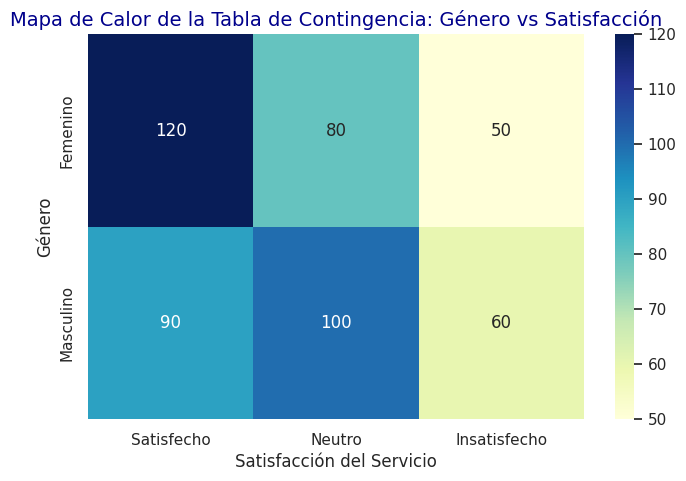

In [14]:
plt.figure(figsize=(8, 5))
sns.heatmap(datos_observados, annot=True, cmap="YlGnBu", fmt="d", cbar=True, annot_kws={'size': 12})
plt.title("Mapa de Calor de la Tabla de Contingencia: Género vs Satisfacción", fontsize=14, color="DarkBlue")
plt.ylabel("Género")
plt.xlabel("Satisfacción del Servicio")
plt.show()


### Análisis Visual: Tabla de Contingencia y Mapa de Calor ($\chi^2$)

| Componente del Gráfico | Qué vemos en la Imagen | Interpretación (Contexto Chi-Cuadrado) |
| :--- | :--- | :--- |
| <span style="color:#1565C0">**Tipo de Gráfico**</span> | <span style="background-color:#E3F2FD; color:#0D47A1; padding:2px 5px; border-radius:3px;">Mapa de Calor (*Heatmap*)</span> | • Colorea las celdas según la cantidad de respuestas (frecuencia).<br>• Tonos oscuros = Mayor concentración de datos.<br>• Tonos claros = Menor concentración. |
| <span style="color:#2E7D32">**Las Variables**</span> | <span style="background-color:#E8F5E9; color:#1B5E20; padding:2px 5px; border-radius:3px;">100% Cualitativas</span> | • No hay promedios ni varianzas aquí. Solo estamos contando "cabezas" distribuidas en categorías (Género vs Nivel de Satisfacción). |
| <span style="color:#E65100">**Patrón Femenino**</span> | <span style="background-color:#FFF3E0; color:#E65100; padding:2px 5px; border-radius:3px;">Fuerte azul oscuro a la izquierda</span> | • La mayor concentración está en "Satisfecho" (120).<br>• Visualmente, este grupo tiende a valorar el servicio positivamente. |
| <span style="color:#6A1B9A">**Patrón Masculino**</span> | <span style="background-color:#F3E5F5; color:#4A148C; padding:2px 5px; border-radius:3px;">Azul oscuro en el centro</span> | • El bloque principal se ubica en "Neutro" (100).<br>• Tienen una distribución distinta al grupo femenino, mostrando una postura más indiferente. |
| <span style="color:#C62828">**El Objetivo Inferencial**</span>| <span style="background-color:#FFEBEE; color:#B71C1C; padding:2px 5px; border-radius:3px;">¿Dependencia o Azar?</span> | • La prueba estadística evaluará si esta diferencia visual de opiniones es estadísticamente significativa o si es producto del azar de esta muestra. |

> **Veredicto Preliminar (Prueba $\chi^2$):** > Las Hipótesis para este escenario son:
> * **$H_0$ (Independencia):** El nivel de satisfacción **NO** depende del género (son independientes).
> * **$H_1$ (Dependencia):** Existe una relación o asociación entre el género y cómo perciben el servicio.
>
> *La intuición visual nos dice que sí hay diferencias de comportamiento entre los grupos. Si la prueba de Chi-Cuadrado arroja un $p$-valor $\le 0.05$, rechazaremos $H_0$ y confirmaremos que la satisfacción está sesgada estadísticamente por el género del cliente.*